# 🔄 Sentiment Classification Pipeline (RoBERTa Fine‑Tuning)

Raw review text  
      │  
      ▼  
**RoBERTa byte-level BPE tokenizer** (`roberta-base`, vocab = 50,265)  
→ `<s>` tokens … `</s>` `<pad>` … (truncate/pad to 256)  
      │  
      ▼  
**Inputs:**  
- `input_ids` (batch × 256)  
- `attention_mask` (batch × 256)  

---

┌───────────────────────────────────────────────┐  
│ **RoBERTa-base encoder (pre-trained)**        │  
│ • Token + position embeddings                 │  
│ • 12 Transformer layers                       │  
│   – 12 attention heads                        │  
│   – Hidden size = 768                         │  
│ • ~125M parameters, all fine‑tuned            │  
└───────────────────────────────────────────────┘  

      │  
      ▼  
**`<s>` vector** (batch × 768)  
      │  
      ▼  
**Classification head** (new, randomly initialized):  
Dropout (p = 0.1) → Linear (768 → 768) + tanh → Dropout (p = 0.1) → Linear (768 → 2)  
      │  
      ▼  
**Logits** (batch × 2)  
      │  
      ▼  
**Prediction:** `argmax` → 0 = negative, 1 = positive


# ⚙️ Training Configuration

| Component   | Details                                                                 |
|-------------|-------------------------------------------------------------------------|
| **Input**   | Token IDs + attention mask, each of shape (batch × 256)                 |
| **Output**  | 2 logits per review → predicted label (0 = negative, 1 = positive)      |
| **Loss**    | Cross-entropy                                                           |
| **Optimiser** | AdamW, LR = 2e-5, weight decay = 0.01                                 |
| **Schedule** | Linear warm-up (10% of steps), then linear decay to 0                  |
| **Batch Size** | 16                                                                   |
| **Epochs**  | Up to 8; keep the epoch with the best validation macro-F1               |
| **Other**   | Gradient clipping = 1.0, fp16 mixed precision, deterministic mode, seed = 42 |
| **Data**    | 6,660 training / 741 validation reviews (stratified 90/10 split of train.json) |


<b>Import Libraries<b>

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [2]:
SEED = 0
MODEL_NAME = 'roberta-base'
MAX_LEN = 256 #Can Change this value to 512 if you have enough GPU memory

In [3]:
train_df = pd.read_json('../Dataset/train.json')
print(train_df.shape)

(7401, 2)


In [4]:
train_df.head()

,reviews,sentiments
0,I bought this belt for my daughter in-law for ...,1
1,The size was perfect and so was the color. It...,1
2,"Fits and feels good, esp. for doing a swim rac...",1
3,These socks are absolutely the best. I take pi...,1
4,Thank you so much for the speedy delivery they...,1


In [5]:
test_df = pd.read_json('../Dataset/test.json')
print(test_df.shape)

(1851, 1)


In [6]:
test_df.head()

,reviews
0,I bought 2 sleepers. sleeper had holes in the...
1,I dare say these are just about the sexiest th...
2,"everything about the transaction (price, deliv..."
3,"Not bad for just a shirt. Very durable, and m..."
4,These are truly wrinkle free and longer than t...


<b>Using RoBERTa as Tokenizer<b>

In [7]:
# 90/10 split, stratified so both keep the same 85/15 positive/negative ratio
tr_df, val_df = train_test_split(train_df, test_size=0.1,
                                 stratify=train_df['sentiments'], random_state=SEED)
print(tr_df.shape, val_df.shape)

(6660, 2) (741, 2)


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(list(texts), padding='max_length', truncation=True,
                     max_length=MAX_LEN, return_tensors='pt')

tr_enc   = encode(tr_df['reviews'])
val_enc  = encode(val_df['reviews'])
test_enc = encode(test_df['reviews'])

print(tr_enc['input_ids'].shape, val_enc['input_ids'].shape, test_enc['input_ids'].shape)
print(tokenizer.convert_ids_to_tokens(tr_enc['input_ids'][0][:20]))

torch.Size([6660, 256]) torch.Size([741, 256]) torch.Size([1851, 256])
['<s>', 'This', 'Ġslee', 'vel', 'ess', 'Ġtank', 'Ġfrom', 'ĠCK', 'Ġis', 'Ġone', 'Ġof', 'Ġthe', 'Ġbest', 'ĠI', "'ve", 'Ġtried', 'Ġ-', 'Ġits', 'Ġsoft', 'Ġcotton']


<b>IMPORT and Hyperparameters<b>

In [9]:
import random, time
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DETERMINISTIC = False   # True = bit-for-bit reproducible runs

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = DETERMINISTIC
    torch.backends.cudnn.benchmark = not DETERMINISTIC
    torch.use_deterministic_algorithms(DETERMINISTIC)
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

BATCH_SIZE = 16
EPOCHS = 8
LR = 2e-5

cuda


# ⚙️ Training Settings

| Setting       | What it Controls                                                                 | Sensible Range        |
|---------------|----------------------------------------------------------------------------------|-----------------------|
| **SEED**      | Random initialization for reproducibility. Ensures results can be replicated.    | Any fixed integer     |
| **BATCH_SIZE**| How many reviews the model looks at before each adjustment (depends on GPU memory). Smaller = more updates, larger = smoother updates but higher memory use. | 16 or 32              |
| **EPOCHS**    | How many full passes through the training set. Too few = underfitting, too many = plateau/overfitting. | 2–8                   |
| **LR**        | How big each adjustment is (learning rate). Most critical hyperparameter for BERT fine‑tuning. | 2e‑5, 3e‑5, 5e‑5      |


<b>Load Datasets<b>

In [10]:
tr_ds   = TensorDataset(tr_enc['input_ids'],  tr_enc['attention_mask'],  torch.tensor(tr_df['sentiments'].values))
val_ds  = TensorDataset(val_enc['input_ids'], val_enc['attention_mask'], torch.tensor(val_df['sentiments'].values))
test_ds = TensorDataset(test_enc['input_ids'], test_enc['attention_mask'])

tr_loader   = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader  = DataLoader(val_ds,  batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(tr_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
loss_fn = torch.nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler(enabled=device.type == 'cuda')

@torch.no_grad()
def predict(loader):
    model.eval(); preds = []
    for batch in loader:
        ids, mask = batch[0].to(device), batch[1].to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            logits = model(input_ids=ids, attention_mask=mask).logits
        preds.append(logits.argmax(-1).cpu())
    return torch.cat(preds).numpy()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<b>Training Loop<b>

In [12]:
best_f1, best_state, history = 0, None, []
cms = []
y_val = val_df['sentiments'].values

for epoch in range(1, EPOCHS + 1):
    model.train(); total_loss = 0; t0 = time.time()
    for ids, mask, labels in tr_loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            loss = loss_fn(model(input_ids=ids, attention_mask=mask).logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total_loss += loss.item()

    val_pred = predict(val_loader)
    acc, f1 = accuracy_score(y_val, val_pred), f1_score(y_val, val_pred, average='macro')
    history.append((epoch, total_loss / len(tr_loader), acc, f1))
    cms.append(confusion_matrix(y_val, val_pred, labels=[0, 1]))
    print(f'Epoch {epoch}: train loss {total_loss/len(tr_loader):.4f} | val acc {acc:.4f} | val macro-F1 {f1:.4f} | {time.time()-t0:.0f}s')

    if f1 > best_f1:   # keep the best epoch, not the last
        best_f1 = f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(classification_report(y_val, predict(val_loader), target_names=['negative', 'positive'], digits=4))


Epoch 1: train loss 0.3079 | val acc 0.9622 | val macro-F1 0.9229 | 87s
Epoch 2: train loss 0.1390 | val acc 0.9595 | val macro-F1 0.9140 | 87s
Epoch 3: train loss 0.0817 | val acc 0.9703 | val macro-F1 0.9417 | 89s
Epoch 4: train loss 0.0436 | val acc 0.9663 | val macro-F1 0.9281 | 90s
Epoch 5: train loss 0.0251 | val acc 0.9703 | val macro-F1 0.9385 | 89s
Epoch 6: train loss 0.0146 | val acc 0.9703 | val macro-F1 0.9390 | 91s
Epoch 7: train loss 0.0100 | val acc 0.9703 | val macro-F1 0.9380 | 85s
Epoch 8: train loss 0.0044 | val acc 0.9730 | val macro-F1 0.9441 | 87s
              precision    recall  f1-score   support

    negative     0.9400    0.8704    0.9038       108
    positive     0.9782    0.9905    0.9843       633

    accuracy                         0.9730       741
   macro avg     0.9591    0.9304    0.9441       741
weighted avg     0.9726    0.9730    0.9726       741



In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})
CM_CMAP = LinearSegmentedColormap.from_list('blues', ['#cde2fb', '#6da7ec', '#2a78d6', '#184f95', '#0d366b'])

def plot_learning_curves(history, title='Learning curves', save_as=None):
    ep   = [h[0] for h in history]
    loss = [h[1] for h in history]
    acc  = [h[2] for h in history]
    f1   = [h[3] for h in history]
    best = int(np.argmax(f1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    # Left: training loss
    ax1.plot(ep, loss, color=BLUE, lw=2, marker='o', ms=7, mec='white', mew=1.5)
    ax1.set_title('Training loss', loc='left', color=INK, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')

    # Right: validation accuracy and macro-F1 (same 0-1 scale -> one axis)
    ax2.plot(ep, acc, color=BLUE,   lw=2, marker='o', ms=7, mec='white', mew=1.5, label='Val accuracy')
    ax2.plot(ep, f1,  color=ORANGE, lw=2, marker='s', ms=7, mec='white', mew=1.5, label='Val macro-F1')
    ax2.text(ep[-1] + 0.15, acc[-1], 'Accuracy', color=MUTED, va='center')
    ax2.text(ep[-1] + 0.15, f1[-1],  'Macro-F1', color=MUTED, va='center')
    ax2.annotate(f'Best epoch {ep[best]}\nF1 = {f1[best]:.4f}', xy=(ep[best], f1[best]),
                 xytext=(0, -38), textcoords='offset points', ha='center', color=INK, fontsize=9,
                 arrowprops=dict(arrowstyle='-', color=MUTED, lw=1))
    ax2.set_title('Validation performance', loc='left', color=INK, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
    ax2.set_xlim(ep[0] - 0.3, ep[-1] + 1.3)
    ax2.legend(frameon=False, loc='lower right')

    for ax in (ax1, ax2):
        ax.set_xticks(ep)
        ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
    fig.suptitle(title, x=0.01, ha='left', color=INK, fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save_as: fig.savefig(save_as, dpi=200, bbox_inches='tight')
    plt.show()

def plot_confusion_matrices(cms, history, labels=('Negative', 'Positive'), save_as=None):
    n = len(cms); cols = min(4, n); rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.1 * cols, 3.0 * rows), squeeze=False)
    best = int(np.argmax([h[3] for h in history]))
    for i, ax in enumerate(axes.flat):
        if i >= n: ax.axis('off'); continue
        cm = cms[i]
        pct = cm / cm.sum(axis=1, keepdims=True)  # shade by % of true class (recall), not raw count
        ax.imshow(pct, cmap=CM_CMAP, vmin=0, vmax=1)
        for r in range(2):
            for c in range(2):
                v = cm[r, c]
                ax.text(c, r, f'{v}\n{pct[r, c]:.0%}', ha='center', va='center', fontsize=10,
                        color='white' if pct[r, c] > 0.45 else INK)
        ax.set_xticks([0, 1], labels); ax.set_yticks([0, 1], labels)
        ax.tick_params(length=0)
        for s in ax.spines.values(): s.set_visible(False)
        star = '  ★ best' if i == best else ''
        ax.set_title(f'Epoch {history[i][0]}  ·  F1 {history[i][3]:.4f}{star}', fontsize=9.5,
                     color=INK, fontweight='bold' if i == best else 'normal')
        if i % cols == 0: ax.set_ylabel('True label')
        if i // cols == rows - 1: ax.set_xlabel('Predicted label')
    fig.suptitle('Validation confusion matrix per epoch  (count, % of true class)',
                 x=0.01, ha='left', color=INK, fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save_as: fig.savefig(save_as, dpi=200, bbox_inches='tight')
    plt.show()


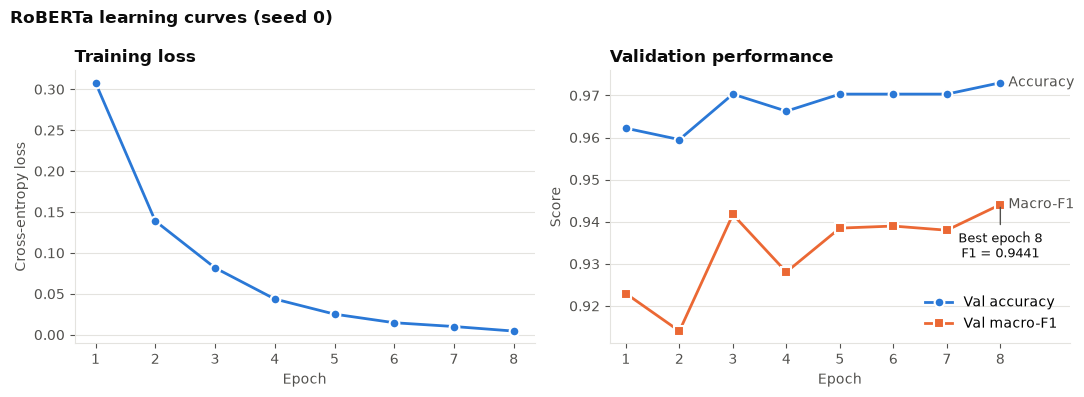

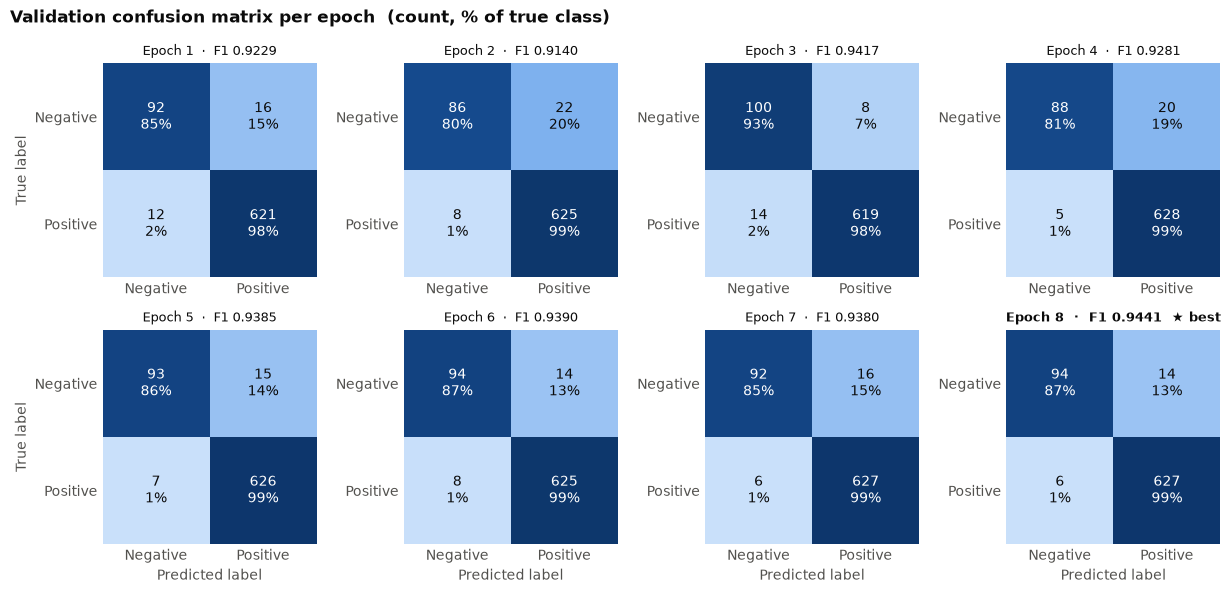

In [14]:
plot_learning_curves(history, title=f'RoBERTa learning curves (seed {SEED})', save_as=f'roberta_learning_curves_seed{SEED}.png')
plot_confusion_matrices(cms, history, save_as=f'roberta_confusion_matrices_seed{SEED}.png')

# 📝 Hyperparameter Tuning Strategy

## Step 1 — Learning Rate
- **What it controls:** Size of each weight adjustment.
- **Impact:** Has the **biggest effect** on BERT fine‑tuning.  
  - A poor LR can ruin training entirely.
- **Plan:** Fix `BATCH_SIZE = 16` and try:
  - `2e-5`
  - `3e-5`
  - `5e-5`

---

## Step 2 — Batch Size
- **What it controls:** How many reviews the model sees before each update.
- **Impact:** Mostly shifts the score slightly, but interacts with LR.
- **Plan:** Using the best LR from Step 1, compare:
  - `BATCH_SIZE = 16`
  - `BATCH_SIZE = 32`

---

## Step 3 — Epochs
- **What it controls:** How many full passes through the training set.
- **Impact:** Depends on LR and batch size; not worth tuning separately.
- **Plan:** Train each run for **4–5 epochs** and read off where validation **macro‑F1 peaks**.  
  - Example: In your 8‑epoch run, performance plateaued after epoch 4.

---

## Practical Note
- **Order matters:** Tune LR first, then batch size, then epochs.  
- **Efficiency:** This saves time by avoiding unnecessary long runs with poor hyperparameters.


# 📊 Metric Trends

| Column        | Meaning                                                                 |
|---------------|-------------------------------------------------------------------------|
| **Train Loss** | How wrong the model is on reviews it learns from (lower is better)      |
| **Val Accuracy** | Share of the 741 held-back reviews it gets right                       |
| **Val Macro-F1** | Score that weights positive and negative reviews equally               |


---

**Validation on Test.json**

In [15]:
SEED       = 42
MODEL_NAME = 'roberta-base'
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 5      # best epoch kept by validation macro-F1
LR         = 2e-5

In [16]:
@torch.no_grad()
def predict_proba(loader):
    model.eval(); probs = []
    for batch in loader:
        ids, mask = batch[0].to(device), batch[1].to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            logits = model(input_ids=ids, attention_mask=mask).logits
        probs.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu())
    return torch.cat(probs).numpy()

test_prob = predict_proba(test_loader)            # probability the review is positive
test_pred = (test_prob >= 0.5).astype(int)

# Submission file (same format as the template)
submission = pd.DataFrame({'reviews': test_df['reviews'], 'predictions': test_pred})
submission.to_csv('submission_roberta.csv', index=False)
print('Saved submission.csv:', submission.shape)
print(submission['predictions'].value_counts().rename({1: 'positive', 0: 'negative'}))

# Look at the results
results = test_df.assign(pred=test_pred, p_positive=test_prob.round(3))
pd.set_option('display.max_colwidth', 250)

Saved submission.csv: (1851, 2)
predictions
positive    1595
negative     256
Name: count, dtype: int64


In [17]:
results.sort_values('p_positive', ascending=False).head(5) 

,reviews,pred,p_positive
1850,"Most umbrellas handle a light rain well, but leave you with wet pants during heavy rains. This umbrella is essential equipment for keeping you dry during downpours. I use it for the walking part of my commute through Washington, DC thunderstorm...",1,1.0
1849,"These shoers were for my daughter. She loves them! As long as she is happy with them, I am happy with them. Adidas has done a great job with supplying kids shoes for athletics. That is the only kind of shoe, we as a family will wear. Keep up...",1,1.0
1,"I dare say these are just about the sexiest things I've ever worn. Oh I've had and have G-strings, have some pretty skimpy ones too. But a crotchless G-String, masqurading as a crotchless pantie, what a concept. Try going outside in a short skirt...",1,1.0
2,"everything about the transaction (price, delivery time, quality of item) was great. I wouldn't hesitate to purchase something again from this seller",1,1.0
3,"Not bad for just a shirt. Very durable, and matched my teams colors perfectly. Its just a shirt, but it helped my team and I go on to greatness.....",1,1.0


In [18]:
results.sort_values('p_positive').head(5)

,reviews,pred,p_positive
0,I bought 2 sleepers. sleeper had holes in the arm pit area and the other sleeper had a whole where the neck trim should of been sewed on. A real waste of my money,0,0.0
47,"Sadly, this well designed item doesn't work for me. It comes detached from its clip while I'm exercising and plunges to the floor dragging my headphones off",0,0.0
1844,"Be warned that the business card side is deep enough to hold 50 cards. I bought this wallet only to hold a few credit cards, my ID and some cash. Hence, there is a lot of wasted space in my wallet. From the picture, it looks as though the busi...",0,0.0
24,"I never receive this ITEM, i want may money back or replace my order",0,0.0
25,"I received my sunglasses last week, they are increibles but they arrived in deficient conditions. they have three lines on them, and simply I feel that I lost my money. I think that you should pay attention to the way eyeglasses are packed for t...",0,0.0


In [19]:
results.iloc[(results['p_positive'] - 0.5).abs().argsort()].head(10)

,reviews,pred,p_positive
1143,"Be careful, this runs REALLY small. I got the 18-24 for my 14 month old, and it would fit better on an average 6 month old. Otherwise, it seems of nice quality",0,0.347
1318,"The slippers are well made and nice-looking, but they were small for their stated size & will have to be exchanged",1,0.695
1308,The item is not my concern; I still have not even received it,0,0.094
646,My Male Color Chart does not have Lapis or Heather so I am unsure what color I am ordering. It would be very helpfull to have the colors next to the names in future products,1,0.909
1228,"Item was nice, but not true to size. The extra large was hanging off of me.",0,0.032
444,May need to get larger size depending on how tight you want it to fi,0,0.029
290,Returns and exchanges are very slow - process has taken a month so far,0,0.022
449,"What a fun and stylish way to wear and protect your ipod. It is just so unfortunate that the shipping on this item is $8.49. Yes, you read that right. Over 8 dollars for shipping. And I am talking standard shipping within the United States. ...",0,0.017
37,"i bought a green ipod scok, thinking the it would be that same as the picture they show at the top of the page, but it ended up having a lighter green than what they showed and what i wanted.",0,0.016
1745,"The dress was gorgeous when I received it, however, there was a slight defect with the item. I had planned to wear it on my birthday so there was no time to exchange. PacificPlex was quick at issuing me a refund I will continue to refer people ...",0,0.016


In [20]:
LOW, HIGH = 0.3, 0.7
borderline = results[(results['p_positive'] > LOW) & (results['p_positive'] < HIGH)]
print(len(borderline), 'borderline reviews')
borderline.iloc[(borderline['p_positive'] - 0.5).abs().argsort()]

2 borderline reviews


,reviews,pred,p_positive
1143,"Be careful, this runs REALLY small. I got the 18-24 for my 14 month old, and it would fit better on an average 6 month old. Otherwise, it seems of nice quality",0,0.347
1318,"The slippers are well made and nice-looking, but they were small for their stated size & will have to be exchanged",1,0.695
